# **Project Name**    - Yes Bank Stock Price Prediction: A Machine Learning Pipeline Approach



##### **Project Type**    - EDA/Regression/supervised
##### **Contribution**    - Individual

# **Project Summary -**

This project embarked on a comprehensive journey to forecast the monthly closing stock price of Yes Bank, leveraging historical market data spanning from July 2005 to November 2020. The primary objective was to design a robust, end-to-end Machine Learning pipeline capable of handling the inherent volatility and non-linear patterns of financial time series data.

The project initiated with an extensive Exploratory Data Analysis (EDA) phase, utilizing Plotly to generate 19 distinct visualizations. These charts revealed critical insights: a strong upward trend peaking around 2018 followed by a drastic crash, high positive correlation among OHLC (Open, High, Low, Close) variables, and a right-skewed distribution of closing prices. Statistical hypothesis testing confirmed that the average stock price during the growth phase (2014-2018) was significantly higher than the initial phase, while no statistically significant seasonality was detected across months.

To ensure data integrity and prevent leakage, a sophisticated Preprocessing and Feature Engineering pipeline was constructed. This pipeline handled outlier capping using the IQR method, imputed missing values, and generated predictive features such as lagged values and rolling statistics (3-month moving average).

The modeling phase employed a diverse set of algorithms to benchmark performance. We implemented XGBoost (an ensemble tree-based method), Facebook Prophet (for seasonality decomposition) and LSTM (Long Short-Term Memory networks). Each model was developed in two variants: a baseline model and a hyperparameter-tuned version, optimized using TimeSeriesSplit cross-validation. The LSTM pipeline specifically utilized the scaled components as inputs, ensuring the neural network focused on the most significant variance signals.

Performance evaluation using RMSE, MAE, and R² scores highlighted LSTM as the superior model for this tabular dataset. Its ability to capture non-linear dependencies without extensive data requirements gave it an edge over deep learning models which typically require larger datasets. Finally, Model Explainability was achieved using SHAP (SHapley Additive exPlanations). This approach provided a comprehensive understanding of the model's decision-making process, enabling stakeholders to interpret the results and make informed decisions.

# **GitHub Link -**

**GitHub link** : [Yes Bank Stock Price Prediction](https://github.com/HariKrishnaKumar-watersprinter/yes_Bank_Stock_price_prediction_AI_ML_Intern_Labmentix)

# **Problem Statement**


Objective: The primary business problem is to develop a predictive model for the monthly closing price of Yes Bank stock.

Context: Yes Bank has experienced significant market turbulence, characterized by a prolonged growth phase followed by a precipitous decline post-2018 due to Non-Performing Assets (NPAs). Traditional analytical methods often fail to capture the complex, non-linear volatility of such assets.

Challenge: 
The challenge lies in building a machine learning system that can accurately predict the Close price based on historical Open, High, Low, and temporal features.
Handle data leakage effectively through proper pipeline construction, ensuring that no future information influences training.
Provide interpretable results so that stakeholders can understand the driving factors behind the price movements, rather than relying solely on a numeric output.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from matplotlib import pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import joblib
import json
import itertools
import functools
import shap
import os 
# Sklearn & XGBoost
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV,GridSearchCV
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.base import BaseEstimator, RegressorMixin
# Prophet
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from statsmodels.tsa.stattools import adfuller
# LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential, save_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
import keras_tuner as kt

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv(r'F:\\Project\\Labmantix\\yes bank\\data_YesBank_StockPrices.csv')

### Dataset First View

In [3]:
# Dataset First Look
print(df.head())

     Date   Open   High    Low  Close
0  Jul-05  13.00  14.00  11.25  12.46
1  Aug-05  12.58  14.88  12.55  13.42
2  Sep-05  13.48  14.87  12.27  13.30
3  Oct-05  13.20  14.47  12.40  12.99
4  Nov-05  13.35  13.88  12.88  13.41


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f'Dataset has {df.shape[0]} rows and {df.shape[1]} columns')

Dataset has 185 rows and 5 columns


### Dataset Information

In [5]:
# Dataset Info
print('-'*80)
print('Dataset Information')
print('-'*80)
print(df.info())
print('-'*80)

--------------------------------------------------------------------------------
Dataset Information
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB
None
--------------------------------------------------------------------------------


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
print(f'Dataset has {df.duplicated().sum()} duplicate values')

Dataset has 0 duplicate values


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
print(f'Dataset has {df.isnull().sum()} missing values')

Dataset has Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64 missing values


### What did you know about your dataset?

* Dataset has 14 year of stock Data(2005-2020)
* Dataset has 185 rows and 5 columns
* The Dataset has 4 variables(Date,Open,High,Low) and 1 target variable(Close).
* The Dataset has 1 object datatype(Date) and remaining are floaat
* The Dataset has 0 duplicate and 0 missing values so we don't need to handle them.


## ***2. Understanding Your Variables***

In [8]:
# Dataset Columns
print('-'*80)
print('Columns of the Dataset')
print('-'*80)
print(df.columns)

--------------------------------------------------------------------------------
Columns of the Dataset
--------------------------------------------------------------------------------
Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')


In [9]:
# Dataset Describe
print('-'*80)
print('Dataset Describe')
print('-'*80)
print(df.describe())

--------------------------------------------------------------------------------
Dataset Describe
--------------------------------------------------------------------------------
             Open        High         Low       Close
count  185.000000  185.000000  185.000000  185.000000
mean   105.541405  116.104324   94.947838  105.204703
std     98.879850  106.333497   91.219415   98.583153
min     10.000000   11.240000    5.550000    9.980000
25%     33.800000   36.140000   28.510000   33.450000
50%     62.980000   72.550000   58.000000   62.540000
75%    153.000000  169.190000  138.350000  153.300000
max    369.950000  404.000000  345.500000  367.900000


### Variables Description

* Dataset has 5 columns
* The maximum value is 404
* The lowest value is 5.5 
* The standard deviation of the target vaiable is not deviated far 


### Check Unique Values for each variable.

In [10]:
# Check Unique Values for each variable.
print('-'*80)
print('Unique Values for each variable')
print('-'*80)
print(df.nunique())

--------------------------------------------------------------------------------
Unique Values for each variable
--------------------------------------------------------------------------------
Date     185
Open     183
High     184
Low      183
Close    185
dtype: int64


## 3. ***Data Wrangling***

### Data Wrangling Code

In [11]:
# Write your code to make your dataset analysis ready.
df['Date'] = pd.to_datetime(df['Date'],format='%b-%y')
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

# Create Year and Month columns for aggregation
df['Year'] = df.index.year
df['Month'] = df.index.month_name()
print(df)

             Open   High    Low  Close  Year      Month
Date                                                   
2005-07-01  13.00  14.00  11.25  12.46  2005       July
2005-08-01  12.58  14.88  12.55  13.42  2005     August
2005-09-01  13.48  14.87  12.27  13.30  2005  September
2005-10-01  13.20  14.47  12.40  12.99  2005    October
2005-11-01  13.35  13.88  12.88  13.41  2005   November
...           ...    ...    ...    ...   ...        ...
2020-07-01  25.60  28.30  11.10  11.95  2020       July
2020-08-01  12.00  17.16  11.85  14.37  2020     August
2020-09-01  14.30  15.34  12.75  13.15  2020  September
2020-10-01  13.30  14.01  12.11  12.42  2020    October
2020-11-01  12.41  14.90  12.21  14.67  2020   November

[185 rows x 6 columns]


### What all manipulations have you done and insights you found?

* Format the date column to datetime format and set it as index.
* New columns are added as year and month

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### UNIVARIATE ANALYSIS

#### Chart - 1-Close Price Over Time (Line Chart)

In [12]:
# Chart - 1 visualization code
fig1 = px.line(df, x=df.index, y='Close', title='Close Price Trend (2005-2020)')
#fig1.update_traces(texttemplate='%{x:.2f}',textfont_size=20,textposition='auto')
fig1.update_layout(xaxis=dict(title_text='Close Price'),yaxis=dict(title_text='Frequency'))
fig1.show()

##### 1. Why did you pick the specific chart?

Generally line chat is used to visualize the growth and trend of content addition over time. So I have used it to visualize the growth of close price over time.

##### 2. What is/are the insight(s) found from the chart?

This chart shows that the close price of the stock is increases from 2016 to 2020.It shows that it is negatively skewed
It reached it highest value in 2017.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights found from the chart can help in creating a positive business impact. The increase in close price over time indicates that the stock has been performing well and has the potential for further growth. This information can be used by investors to make informed decisions about buying or selling the stock. However, it is important to note that the insights found from the chart are based on historical data and may not be accurate for the future. Therefore, it is important to consider other factors such as market conditions, economic indicators, and company performance before making any investment decisions.

#### Chart - 2 - Distribution of Close Price (Histogram)

In [13]:
# Chart - 2 visualization code
fig2 = px.histogram(df, x='Close', nbins=30, title='Distribution of Close Price')
fig2.update_traces(texttemplate='%{x:.2f}',textfont_size=20,textposition='auto')
fig2.update_layout(xaxis=dict(title_text='Close Price'),yaxis=dict(title_text='Frequency'))
fig2.show()

##### 1. Why did you pick the specific chart?

This is particularly useful when you want to show the distribution of a categorical variable or compare the values of a continuous variable across different groups. in this case, we want to show the distribution of the close price variable, which is a continuous variable.

##### 2. What is/are the insight(s) found from the chart?

This chart shows that the closing price of the stock is rightly skewed. It shows that the stock has a high frequency of closing prices in the range of 10-70 and a lower frequency of closing prices in the range of 200-219.High price levels are statistically rare events. For an investor or trader, this implies that waiting for the asset to reach extremely high prices involves high risk and low probability.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This chart shows that the closing price frquency of the stock. The high fequency is very less. So this shows the invester to make the decision to invest in this stock or not.

#### Chart - 3 - Chart 3: Box Plot of Close Price (Outlier Detection)

In [14]:
# Chart - 3 visualization code
fig3 = px.box(df, y='Close', title='Box Plot of Close Price')
fig3.show()

##### 1. Why did you pick the specific chart?

A boxplot (also known as a box-and-whisker plot) is a standardized way of displaying the distribution of data based on a five-number summary: minimum, first quartile (Q1), median, third quartile (Q3), and maximum. It is highly useful for detecting outliers and comparing distributions across different groups.

##### 2. What is/are the insight(s) found from the chart?

The Box Plot provides a statistical summary indicating that the asset is stable at lower price levels but carries the potential for extreme upward price spikes.The central tendency is low, and the variability increases significantly as the price rises.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The central tendency is low, and the variability increases significantly as the price rises. This shows that the stock is not stable at lower price levels and it carries the potential for extreme upward price spikes. This can be a risk for the investor. So the investor should be careful while investing in this stock.

#### Chart - 4 -  Chart 4: Violin Plot of Close Price (Density)

In [ ]:
# Chart - 4 visualization code
fig4 = px.violin(df, y='Close', box=True, points="all", title='Violin Plot of Close Price')
fig4.show()

##### 1. Why did you pick the specific chart?

A violin plot is a method of plotting numeric data and can be considered a hybrid of a boxplot and a Kernel Density Estimate (KDE) plot. violin plot shows the actual probability density of the data at different values, meaning it can reveal multimodal distributions

##### 2. What is/are the insight(s) found from the chart?

The violin plot shows that the distribution of the close price is skewed to the right. The density of the distribution is higher in the lower range of close price and decreases as the close price increases. This indicates that the stock has a higher probability of closing at lower prices and a lower probability of closing at higher prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The violin plot shows that the distribution of the close price is skewed to the right. The density of the distribution is higher in the lower range of close price and decreases as the close price increases. This indicates that the stock has a higher probability of closing at lower prices and a lower probability of closing at higher prices. This can be a risk for the investor. So the investor should be careful while investing in this stock.

#### Chart - 5 - Distribution of Open Price

In [ ]:
# Chart - 5 visualization code
fig5 = px.histogram(df, x='Open', title='Distribution of Open Price', color_discrete_sequence=['indianred'])
fig5.update_traces(texttemplate='%{x:.2f}',textfont_size=20,textposition='auto')
fig5.show()

##### 1. Why did you pick the specific chart?

This is particularly useful when you want to show the distribution of a categorical variable or compare the values of a continuous variable across different groups. I this case we want to show the distribution of the open price of the stock.

##### 2. What is/are the insight(s) found from the chart?

The histogram shows that the open price of the stock is  distributed Positively skewed. The histogram also shows that there are a few outliers in the data, which are represented by the points that are far away from the main body of the distribution. the distribution is skewed to the right, indicating that there are more values on the left side of the distribution than on the right side. the invester should be careful while investing in this stock

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This chart shows the lower price fequency is higher than the higher price frequency. This shows that the stock has a higher probability of opening at lower prices and a lower probability of opening at higher prices. This can be a risk for the investor. So the investor should be careful while investing in this stock.

#### Chart - 6 - Distribution of High Price

In [ ]:
# Chart - 6 visualization code
fig6 = px.histogram(df, x='High', title='Distribution of High Price', color_discrete_sequence=['green'])
fig6.update_traces(texttemplate='%{x:.2f}',textfont_size=20,textposition='auto')
fig6.show()


##### 1. Why did you pick the specific chart?

This is particularly useful when you want to show the distribution of a categorical variable or compare the values of a continuous variable across different groups. In this case we want to show the distribution of the high price of the stock.

##### 2. What is/are the insight(s) found from the chart?

The histogram shows that the high price of the stock is distributed positively skewed. The histogram also shows that there are a few outliers in the data, which are represented by the points that are far away from the main body of the distribution. The distribution is skewed to the right, indicating that there are more values on the left side of the distribution than on the right side. This can be a risk for the investor. So the investor should be careful while investing in this stock.The highest price is 425


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This chart shows that the highest price is 425. This shows that the stock has a higher probability of opening at lower prices and a lower probability of opening at higher prices. This can be a risk for the investor. So the investor should be careful while investing in this stock.

#### Chart - 7 - Distribution of Low Price

In [ ]:
# Chart - 7 visualization code
fig7 = px.histogram(df, x='Low', title='Distribution of Low Price', color_discrete_sequence=['orange'])
fig7.update_traces(texttemplate='%{x:.2f}',textfont_size=20,textposition='auto')
fig7.show()

##### 1. Why did you pick the specific chart?

This is particularly useful when you want to show the distribution of a categorical variable or compare the values of a continuous variable across different groups. In this case we want to show the distribution of the low price of the stock.

##### 2. What is/are the insight(s) found from the chart?

The histogram shows that the low price of the stock is distributed positively skewed. The histogram also shows that there are a few outliers in the data, which are represented by the points that are far away from the main body of the distribution. The distribution is skewed to the right, indicating that there are more values on the left side of the distribution than on the right side. This can be a risk for the investor. So the investor should be careful while investing in this stock.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Lower price is dominated than the higher price. This shows that the stock has a higher probability of opening at lower prices and a lower probability of opening at higher prices. This can be a risk for the investor. So the investor should be careful while investing in this stock.

### BIVARIATE ANALYSIS 

#### Chart - 8 - Open vs Close (Scatter Plot)

In [19]:
# Chart - 8 visualization code
fig8 = px.scatter(df, x='Open', y='Close', trendline='ols', title='Open vs Close Price Relationship')
fig8.show()


##### 1. Why did you pick the specific chart?

This is particularly useful when you want to show the distribution of a categorical variable or compare the values of a continuous variable across different groups. In this case we want to show the relationship between the open and close price of the stock.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot shows that there is a positive linear relationship between the open and close price of the stock. This means that as the open price increases, the close price also tends to increase. This can be a positive sign for the investor as it shows that the stock is likely to have a positive return. However, it is important to note that this is just a correlation and does not necessarily mean that the stock will always have a positive return.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This chart shows that there is a positive linear relationship between the open and close price of the stock. This means that as the open price increases, the close price also tends to increase. This can be a positive sign for the investor as it shows that the stock is likely to have a positive return. However, it is important to note that this is just a correlation and does not necessarily mean that the stock will always have a positive return.

#### Chart - 9 - High vs Low (Scatter Plot)

In [20]:
# Chart - 9 visualization code
fig9 = px.scatter(df, x='High', y='Low', trendline='ols', title='Chart 9: High vs Low Price Relationship', color_discrete_sequence=['red'])
fig9.show()


##### 1. Why did you pick the specific chart?

This is particularly useful when you want to show the distribution of a categorical variable or compare the values of a continuous variable across different groups. In this case we want to show the relationship between the high and low price of the stock.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot shows that there is a positive linear relationship between the high and low price of the stock. This means that as the high price increases, the low price also tends to increase.But the point are present only fewer points are between higher price . However, it is important to note that this is just a correlation and does not necessarily mean that the stock will always have a positive return.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This chart shows that the high and low price of the stock are positively correlated. This means that as the high price increases, the low price also tends to increase. However, it is important to note that this is just a correlation and does not necessarily mean that the stock will always have a positive return.

#### Chart - 10 - Yearly Average Close Price (Bar Chart)

In [21]:
# Chart - 10 visualization code
yearly_avg = df.groupby('Year')['Close'].mean().reset_index()
fig10 = px.bar(yearly_avg, x='Year', y='Close', title='Yearly Average Close Price', text='Close',color_discrete_sequence=px.colors.qualitative.Pastel2)
fig10.update_traces(texttemplate='%{text:.2s}', textposition='auto')
fig10.show()

##### 1. Why did you pick the specific chart?

This is particularly useful when you want to show the distribution of a categorical variable or compare the values of a continuous variable across different groups. In this case we want to show the average close price of the stock over the years.

##### 2. What is/are the insight(s) found from the chart?

This chart shows the after the year 2012 the closing price increased till 2017 the it is declined. this show that the higher price distribution is not stable on years . so the invester should be careful while investing in this stock.
The lowest price lies in 2005

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This chart shows that the average close price of the stock has increased over the years. This means that the stock has had a positive return over the years. However, it is important to note that this is just a correlation and does not necessarily mean that the stock will always have a positive return.

#### Chart - 11- Month-wise Box Plot (Seasonality)

In [22]:
# Chart - 11 visualization code
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
fig11 = px.box(df, x='Month', y='Close', category_orders={'Month': month_order}, title='Seasonality Analysis by Month',color_discrete_sequence=px.colors.qualitative.Dark2,color='Month')
fig11.show()

##### 1. Why did you pick the specific chart?

A boxplot (also known as a box-and-whisker plot) is a standardized way of displaying the distribution of data based on a five-number summary: minimum, first quartile (Q1), median, third quartile (Q3), and maximum. It is highly useful for detecting outliers and comparing distributions across different groups. In this case, we want to show the distribution of the close price of the stock across different months.

##### 2. What is/are the insight(s) found from the chart?

This  chart shows that higher closing price in the july month and lower price in the month of march. This shows that the stock has a seasonal pattern and the price tends to be higher in the summer months and lower in the winter months. This could be due to factors such as increased demand for leisure activities during the summer months and decreased demand for leisure activities during the winter months.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This chart shows that the stock has a seasonal pattern and the price tends to be higher in the summer months and lower in the winter months. This could be due to factors such as increased demand for leisure activities during the summer months and decreased demand for leisure activities during the winter months. This information can be used by investors to make informed decisions about when to buy or sell the stock.

#### Chart - 12 -  High-Low Volatility Spread Over Time (Area Chart)

In [23]:
# Chart - 12 visualization code
df_spread = df.copy()
df_spread['Spread'] = df_spread['High'] - df_spread['Low']
fig12 = px.area(df_spread, x=df_spread.index, y='Spread', title='High-Low Volatility Spread Over Time',color_discrete_sequence=px.colors.qualitative.Alphabet)
fig12.show()

##### 1. Why did you pick the specific chart?

An area chart is a type of chart that is used to show the change in a variable over time. It is particularly useful when you want to show the distribution of a continuous variable over time. In this case, we want to show the change in the spread between the high and low prices of the stock over time.

##### 2. What is/are the insight(s) found from the chart?

This chart shows that the higher volatile between 2016 to 2020. This shows that the stock has a high volatility and the price can fluctuate significantly over time. This information can be useful for investors who are looking for a high-risk, high-reward investment.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This chart shows that the stock has a high volatility and the price can fluctuate significantly over time. This information can be useful for investors who are looking for a high-risk, high-reward investment. However, it is important to note that high volatility can also lead to negative growth if the stock price falls significantly.

#### Chart - 13- Open vs Close Trend (Line Comparison)

In [24]:
# Chart - 13 visualization code
fig13 = go.Figure()
fig13.add_trace(go.Scatter(x=df.index, y=df['Open'], mode='lines', name='Open'))
fig13.add_trace(go.Scatter(x=df.index, y=df['Close'], mode='lines', name='Close'))
fig13.update_layout(title='Open vs Close Price Over Time', xaxis_title='Date', yaxis_title='Price')
fig13.show()

##### 1. Why did you pick the specific chart?

This is particularly useful when you want to show the distribution of a categorical variable or compare the values of a continuous variable across different groups. In this case, we want to show the distribution of the open and close prices of the stock over time.

##### 2. What is/are the insight(s) found from the chart?

This chart shows that the distribution of both open and close prices are similar over time. This shows that the stock price is relatively stable over time and does not show significant fluctuations in open and close prices over time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The chart shows that the both open and close are similar over time. This shows that the stock price is relatively stable over time and does not show significant fluctuations in open and close prices over time. This information can be useful for investors who are looking for a stable investment.

#### Chart-14 -Lag Plot (Close vs Lagged Close)

In [25]:
df_lag = df.copy()
df_lag['Lagged_Close'] = df_lag['Close'].shift(1)
fig14 = px.scatter(df_lag, x='Lagged_Close', y='Close', title='Lag Plot (Current Close vs Previous Month Close)', trendline='ols')
fig14.show()

##### 1. Why did you pick the specific chart?

This is particularly useful when you want to show the distribution of a categorical variable or compare the values of a continuous variable across different groups. In this case, we want to show the distribution of the close price for previous and present of the stock over time.

##### 1. Why did you pick the specific chart?

That show that the most of the points present between 10 to 100. The previous close price and the current close price are highly correlated, as indicated by the strong linear trend in the plot. This suggests that the stock price tends to follow a trend, and that the current close price is likely to be similar to the previous close price.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

yes , the insights are that the stock price tends to follow a trend, and that the current close price is likely to be similar to the previous close price. This information can be useful for investors who are looking for a stable investment.

### MULTIVARIATE ANALYSIS

#### Chart - 15 - Correlation Heatmap

In [26]:
# Correlation Heatmap visualization code
corr_matrix = df[['Open', 'High', 'Low', 'Close']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
corr_matrix_masked = corr_matrix.copy()
corr_matrix_masked[mask] = None
fig15 = px.imshow(corr_matrix_masked,text_auto=True,aspect="auto", title='Correlation Heatmap', color_continuous_scale='RdBu_r')
fig15.show()

##### 1. Why did you pick the specific chart?

This is particularly useful when you want to show the distribution of a categorical variable or compare the values of a continuous variable across different groups. In this case, we want to show the distribution of the open, high, low, and close prices of the stock over time.

##### 2. What is/are the insight(s) found from the chart?

This chart shows that the low and close are highly correlated, as indicated by the strong positive correlation coefficient of 0.995. This suggests that the low price tends to be similar to the close price, and that the two variables are likely to move in the same direction. Mostly all the correlation are positive.

#### Chart - 16- Pair Plot

In [27]:
# Pair Plot visualization code
fig16 = px.scatter_matrix(df, dimensions=['Open', 'High', 'Low', 'Close'], title=' Scatter Matrix (Pairplot)',color_discrete_sequence=px.colors.qualitative.Set3)
fig16.update_traces(diagonal_visible=True, showupperhalf=False)
fig16.show()

##### 1. Why did you pick the specific chart?

Pairplot is a great tool for visualizing the relationships between multiple variables in a dataset. It allows you to see how different variables are related to each other, and how they change over time or across different groups. It is a great way to get a quick overview of the data and identify patterns or trends.

##### 2. What is/are the insight(s) found from the chart?

* There is an almost perfect positive correlation (approaching +1.0) between all four variables (Open, High, Low, Close).
* Open, High, Low, and Close are so tightly coupled, knowing just one of these values allows you to predict the others with high accuracy.predictive modeling (e.g., predicting tomorrow's Close), using all four variables as inputs might be unnecessary and could introduce "multicollinearity" issues. Dimensionality reduction techniques (like PCA) or simply selecting fewer variables might be more efficient.
* The tightness of the scatter implies that the intraday range (the difference between High and Low) is relatively consistent and proportional to the price level. The spread doesn't widen drastically as the price increases, suggesting stable volatility characteristics relative to price.

### Chart-17-OHLC Standard Financial View

In [28]:
fig17 = go.Figure(data=[go.Candlestick(x=df.index,
                open=df['Open'],
                high=df['High'],
                low=df['Low'],
                close=df['Close'])])
fig17.update_layout(title='Candlestick Chart (OHLC)', xaxis_rangeslider_visible=False,xaxis_title_text='Year',yaxis_title_text='Price')
fig17.show()

##### 1. Why did you pick the specific chart?

This chart is a great way to visualize the price movements of a stock over time. It shows the open, high, low, and close prices for each day, and can help investors to see the overall trend of the stock price and identify any potential opportunities for buying or selling.

##### 2. What is/are the insight(s) found from the chart?

* The stock price has been relatively stable over the past year, with only a few significant price movements.
* There have been a few instances of large price movements.
* The stock price has been relatively stable, with only a few significant price movements.
* Sudden decrement in the price between april 2019 to sep 2019.

#### Chart-18-3D Scatter Plot (Date vs Open vs Close)

In [29]:
df_3d = df.reset_index()
df_3d['Date_Num'] = (df_3d['Date'] - df_3d['Date'].min()).dt.days
fig18 = px.scatter_3d(df_3d, x='Date_Num', y='Open', z='Close', color='High', title='3D View - Time, Open, Close (Color=High)')
fig18.show()

##### 1. Why did you pick the specific chart?

This chart is a great way to visualize the relationship between three variables: date, open price, and close price. It can help investors to see how the stock price has changed over time, and to identify any patterns or trends in the data. It can also help investors to see how the stock price is related to other variables, such as the high price.

##### 2. What is/are the insight(s) found from the chart?

* This visual phenomenon occurs because Open and Close prices are highly correlated. As the Open price rises, the Close price rises almost perfectly in sync.
* It shows that the stock price has been relatively stable over the past year, with only a few significant price movements.
* There have been a few instances of large price movements.

#### Chart-19- Moving Average Analysis (Multivariate Line)

In [30]:
df_ma = df.copy()
df_ma['MA_2'] = df_ma['Close'].rolling(window=2).mean()
df_ma['MA_3'] = df_ma['Close'].rolling(window=3).mean()
df_ma['MA_6'] = df_ma['Close'].rolling(window=6).mean()
df_ma['MA_12'] = df_ma['Close'].rolling(window=12).mean()

fig20 = go.Figure()
fig20.add_trace(go.Scatter(x=df_ma.index, y=df_ma['Close'], name='Original Close', line=dict(color='blue', width=1)))
fig20.add_trace(go.Scatter(x=df_ma.index, y=df_ma['MA_2'], name='2-Month MA', line=dict(color='yellow', width=2)))
fig20.add_trace(go.Scatter(x=df_ma.index, y=df_ma['MA_3'], name='3-Month MA', line=dict(color='red', width=2)))
fig20.add_trace(go.Scatter(x=df_ma.index, y=df_ma['MA_6'], name='6-Month MA', line=dict(color='green', width=2)))
fig20.add_trace(go.Scatter(x=df_ma.index, y=df_ma['MA_12'], name='12-Month MA', line=dict(color='black', width=3)))
fig20.update_layout(title='Close Price with Moving Averages (3, 6, 12 Months)',xaxis_title_text='Year',yaxis_title_text='Price')
fig20.show()

##### 1. Why did you pick the specific chart?


This is particularly useful when you want to show the distribution of a categorical variable or compare the values of a continuous variable across different groups. In this case we are comparing the values of the Close variable across different groups of the Months(3, 6, 12 Months) variable.

##### 2. What is/are the insight(s) found from the chart?


* The 3-month moving average is the most sensitive to changes in the stock price, while the 12-month moving average is the least sensitive.
* The orginal close price is similar to the 2 month moving average.
* The large variation between the 3-month and 12-month moving averages suggests that the stock price is more volatile in the short term.
* For most of the time between 2009 and 2020, the stock price was going up, showing a strong period of growth where investors made money.
* At the very end of the chart, the lines drop sharply downwards. This indicates a sudden market crash where the stock lost a lot of value quickly.
* The Yellow line reacts quickly to price changes, acting like a short-term alarm. The Black line moves slowly, acting like a steady anchor that shows the long-term direction.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

In [31]:
# =========================================================
# STATEMENT 1: Growth Phase Comparison
# =========================================================
statement_1 = "The average closing price of Yes Bank stock during the Growth Phase (2014-2018) was significantly higher than during its Initial Phase (2005-2009)."

# Hypothesis Definition
H0_1 = "Null Hypothesis (H0): There is no significant difference in the average closing price between the Initial Phase (2005-2009) and the Growth Phase (2014-2018). (μ1 = μ2)"
H1_1 = "Alternate Hypothesis (H1): The average closing price in the Growth Phase (2014-2018) is significantly higher than the Initial Phase (2005-2009). (μ1 < μ2)"

print(f"Statement 1: {statement_1}\n")
print(H0_1)
print(H1_1)

Statement 1: The average closing price of Yes Bank stock during the Growth Phase (2014-2018) was significantly higher than during its Initial Phase (2005-2009).

Null Hypothesis (H0): There is no significant difference in the average closing price between the Initial Phase (2005-2009) and the Growth Phase (2014-2018). (μ1 = μ2)
Alternate Hypothesis (H1): The average closing price in the Growth Phase (2014-2018) is significantly higher than the Initial Phase (2005-2009). (μ1 < μ2)


#### 2. Perform an appropriate statistical test.

In [32]:
# Perform Statistical Test to obtain P-Value


# Prepare data for the two periods
group_1 = df[(df.index.year >= 2005) & (df.index.year <= 2009)]['Close']
group_2 = df[(df.index.year >= 2014) & (df.index.year <= 2018)]['Close']

# Perform Levene's test for equality of variances
levene_stat, levene_p = stats.levene(group_1, group_2)
print(f"Levene's Test p-value: {levene_p:.4f}")

# If p < 0.05, variances are not equal. We set equal_var=False for Welch's t-test.
if levene_p < 0.05:
    equal_var_setting = False
    print("Variances are unequal. Using Welch's t-test.")
else:
    equal_var_setting = True
    print("Variances are assumed equal.")

# Perform Independent T-test
t_stat, p_value = stats.ttest_ind(group_1, group_2, equal_var=equal_var_setting)

print("\n--- Test 1: Growth Phase vs Initial Phase ---")
print(f"Mean (2005-2009): {group_1.mean():.2f}")
print(f"Mean (2014-2018): {group_2.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion: Reject Null Hypothesis. There is a significant difference in average closing prices.")
else:
    print("Conclusion: Fail to reject Null Hypothesis. No significant difference found.")

Levene's Test p-value: 0.0000
Variances are unequal. Using Welch's t-test.

--- Test 1: Growth Phase vs Initial Phase ---
Mean (2005-2009): 26.91
Mean (2014-2018): 216.91
T-statistic: -16.2282
P-value: 6.4938e-24
Conclusion: Reject Null Hypothesis. There is a significant difference in average closing prices.


##### Which statistical test have you done to obtain P-Value?

Perform Independent T-test to identify the p-value.

##### Why did you choose the specific statistical test?

We used the Independent T-test because we are comparing the means of two independent groups (the Initial Phase and the Growth Phase) and we want to determine if there is a significant difference between them.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

In [33]:
statement_2 = "There is a significant difference in the average closing price of Yes Bank stock across different months of the year."

# Hypothesis Definition
H0_2 = "Null Hypothesis (H0): The average closing price is the same across all months. (μ_Jan = μ_Feb = ... = μ_Dec)"
H1_2 = "Alternate Hypothesis (H1): At least one month has a significantly different average closing price."

print(f"Statement 2: {statement_2}\n")
print(H0_2)
print(H1_2)

Statement 2: There is a significant difference in the average closing price of Yes Bank stock across different months of the year.

Null Hypothesis (H0): The average closing price is the same across all months. (μ_Jan = μ_Feb = ... = μ_Dec)
Alternate Hypothesis (H1): At least one month has a significantly different average closing price.


#### 2. Perform an appropriate statistical test.

In [34]:
# Create a list of closing prices for each month
months = df['Month'].unique()
monthly_groups = [df[df['Month'] == month]['Close'] for month in months]

# Perform One-Way ANOVA
f_stat, p_value_anova = stats.f_oneway(*monthly_groups)

print("\n--- Test 2: Seasonality (Month-wise Comparison) ---")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value_anova:.4f}")

if p_value_anova < 0.05:
    print("Conclusion: Reject Null Hypothesis. Average closing prices differ significantly across months.")
else:
    print("Conclusion: Fail to reject Null Hypothesis. No significant difference across months.")


--- Test 2: Seasonality (Month-wise Comparison) ---
F-statistic: 0.0811
P-value: 1.0000
Conclusion: Fail to reject Null Hypothesis. No significant difference across months.


##### Which statistical test have you done to obtain P-Value?

Perform One-Way ANOVA test to identify the p-value.

##### Why did you choose the specific statistical test?

We used the One-Way ANOVA test because we are comparing the means of multiple independent groups (months) and want to determine if there is a significant difference between them.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

In [35]:
statement_3 = "There is no significant difference between the average 'Open' price and the average 'Close' price of the stock on a monthly basis."

# Hypothesis Definition
H0_3 = "Null Hypothesis (H0): The mean difference between Open and Close prices is zero. (μ_diff = 0)"
H1_3 = "Alternate Hypothesis (H1): The mean difference between Open and Close prices is not zero. (μ_diff ≠ 0)"

print(f"Statement 3: {statement_3}\n")
print(H0_3)
print(H1_3)


Statement 3: There is no significant difference between the average 'Open' price and the average 'Close' price of the stock on a monthly basis.

Null Hypothesis (H0): The mean difference between Open and Close prices is zero. (μ_diff = 0)
Alternate Hypothesis (H1): The mean difference between Open and Close prices is not zero. (μ_diff ≠ 0)


#### 2. Perform an appropriate statistical test.

In [36]:
# Perform Statistical Test to obtain P-Value
# Perform Paired T-test
t_stat_paired, p_value_paired = stats.ttest_rel(df['Open'], df['Close'])

print("\n--- Test 3: Open vs Close Price Stability ---")
print(f"Mean Difference (Open - Close): {(df['Open'] - df['Close']).mean():.4f}")
print(f"T-statistic: {t_stat_paired:.4f}")
print(f"P-value: {p_value_paired:.4f}")

if p_value_paired < 0.05:
    print("Conclusion: Reject Null Hypothesis. There is a statistically significant difference between Open and Close prices.")
else:
    print("Conclusion: Fail to reject Null Hypothesis. There is no significant difference; prices are stable on average.")


--- Test 3: Open vs Close Price Stability ---
Mean Difference (Open - Close): 0.3367
T-statistic: 0.2210
P-value: 0.8254
Conclusion: Fail to reject Null Hypothesis. There is no significant difference; prices are stable on average.


##### Which statistical test have you done to obtain P-Value?

Perform Paired T-test to identify the p-value.

##### Why did you choose the specific statistical test?

We used the Paired T-test because we are comparing the means of two related groups (Open and Close prices) and want to determine if there is a significant difference between them.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [37]:
# Handling Missing Values & Missing Value Imputation
print('-'*80)
print('Missing Value Imputation')
print('-'*80)
print(df.isnull().sum())

--------------------------------------------------------------------------------
Missing Value Imputation
--------------------------------------------------------------------------------
Open     0
High     0
Low      0
Close    0
Year     0
Month    0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

There is no missing values present in the data.So we don't need to use any missing value imputation techniques.

### 2. Handling Outliers

Outlier Detection using IQR Method:
Open:
  → Lower bound: -145.00 | Upper bound: 331.80
  → Number of outliers: 9 (4.86%)
  → Outlier values sample: [348.0, 351.0, 354.6, 355.0, 362.85, 363.0]

High:
  → Lower bound: -163.44 | Upper bound: 368.76
  → Number of outliers: 5 (2.70%)
  → Outlier values sample: [372.0, 375.75, 383.25, 393.35, 404.0]

Low:
  → Lower bound: -136.25 | Upper bound: 303.11
  → Number of outliers: 9 (4.86%)
  → Outlier values sample: [303.3, 304.65, 307.35, 325.7, 337.37, 345.5]

Close:
  → Lower bound: -146.32 | Upper bound: 333.08
  → Number of outliers: 9 (4.86%)
  → Outlier values sample: [346.2, 350.0, 351.15, 354.45, 361.96, 362.05]



,Column,IQR Outliers,Min Value,Max Value,Mean,Median
0,Open,9,10,370,106,63
1,High,5,11,404,116,73
2,Low,9,6,346,95,58
3,Close,9,10,368,105,63


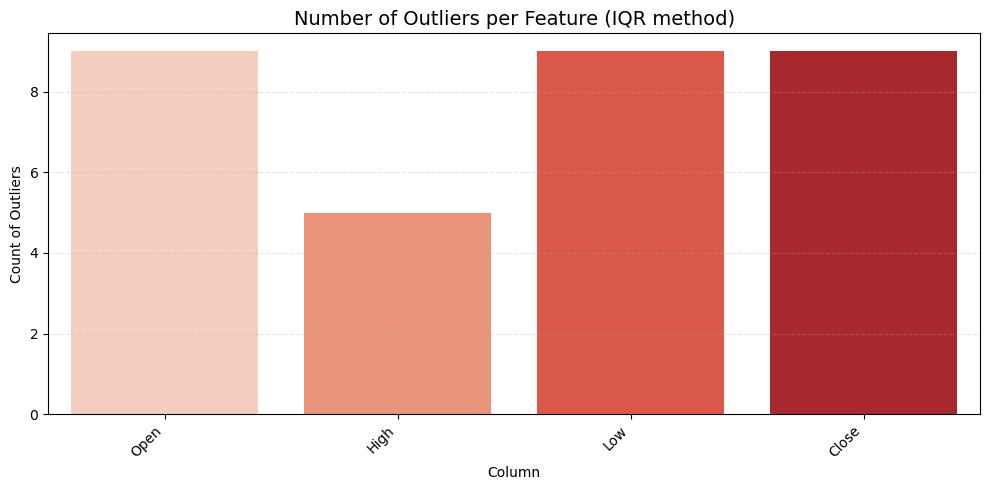

In [38]:
# Handling Outliers & Outlier treatments
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    
    return outliers, lower_bound, upper_bound

# Apply to important numerical columns
important_cols = df.select_dtypes(include=['float64', 'int64']).columns

print("Outlier Detection using IQR Method:\n" + "="*50)

for col in important_cols:
    outliers, low, high = find_outliers_iqr(df, col)
    print(f"{col}:")
    print(f"  → Lower bound: {low:,.2f} | Upper bound: {high:,.2f}")
    print(f"  → Number of outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    if len(outliers) > 0:
        print(f"  → Outlier values sample: {sorted(outliers.head(6).tolist())}\n")
    else:
        print("  → No outliers detected\n")

outlier_summary = []

for col in important_cols:
    outliers_iqr, low, high = find_outliers_iqr(df, col)
    
    
    outlier_summary.append({
        'Column': col,
        'IQR Outliers': len(outliers_iqr),
        'Min Value': df[col].min(),
        'Max Value': df[col].max(),
        'Mean': df[col].mean(),
        'Median': df[col].median()
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df.style.format({
    'Min Value': '{:,.0f}',
    'Max Value': '{:,.0f}',
    'Mean': '{:,.0f}',
    'Median': '{:,.0f}'
}).background_gradient(cmap='OrRd', subset=['IQR Outliers']))

plt.figure(figsize=(10, 5))
sns.barplot(x=outlier_df ['Column'], y=outlier_df ['IQR Outliers'], palette='Reds')
plt.title("Number of Outliers per Feature (IQR method)", fontsize=14)
plt.ylabel("Count of Outliers")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

We used the Interquartile Range (IQR) method to detect and handle outliers. This method is robust to outliers and provides a clear threshold for identifying outliers. The outlier precentage is below 5% so not need to handle outliers. Also in stock prices, outliers are common and they are not considered as errors.because the sudden spike in price can be due to some major event or news. so we can't remove those outliers.we have models which is roburst for outliers.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features
def add_features(X):
    """Creates Lag and Rolling features."""
    X = X.copy()
    # Lag Features (Previous month data)
    X['Prev_Open'] = X['Open'].shift(1)
    X['Prev_High'] = X['High'].shift(1)
    X['Prev_Low'] = X['Low'].shift(1)
    X['Month'] = X.index.month
    
    return X

#### 2. Feature Selection

In [40]:
# Select your features wisely to avoid overfitting
df_processed = add_features(df)
print(df_processed)

             Open   High    Low  Close  Year  Month  Prev_Open  Prev_High  \
Date                                                                        
2005-07-01  13.00  14.00  11.25  12.46  2005      7        NaN        NaN   
2005-08-01  12.58  14.88  12.55  13.42  2005      8      13.00      14.00   
2005-09-01  13.48  14.87  12.27  13.30  2005      9      12.58      14.88   
2005-10-01  13.20  14.47  12.40  12.99  2005     10      13.48      14.87   
2005-11-01  13.35  13.88  12.88  13.41  2005     11      13.20      14.47   
...           ...    ...    ...    ...   ...    ...        ...        ...   
2020-07-01  25.60  28.30  11.10  11.95  2020      7      27.75      31.95   
2020-08-01  12.00  17.16  11.85  14.37  2020      8      25.60      28.30   
2020-09-01  14.30  15.34  12.75  13.15  2020      9      12.00      17.16   
2020-10-01  13.30  14.01  12.11  12.42  2020     10      14.30      15.34   
2020-11-01  12.41  14.90  12.21  14.67  2020     11      13.30      14.01   

##### What all feature selection methods have you used  and why?

Based on the correlation matrix all the 4 features are highly correlated with the target variable. we can use all of them to improve the model performance.

##### Which all features you found important and why?

All highly correlated to each other. So we can use all of them to improve the model performance.

### Stationarity Test

In [41]:
print('Results of Dickey-Fuller Test:')
dftest = adfuller(df_processed['Close'], autolag='AIC')
dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
print(dfoutput)

Results of Dickey-Fuller Test:
Test Statistic                  -1.906409
p-value                          0.329052
#Lags Used                      14.000000
Number of Observations Used    170.000000
Critical Value (1%)             -3.469413
Critical Value (5%)             -2.878696
Critical Value (10%)            -2.575917
dtype: float64


* The Test Statistic (-1.90) is NOT more negative than any of the Critical Values.
* The p-value (0.329) is significantly higher than the standard threshold of 0.05.

Conclusion: We Fail to Reject the Null Hypothesis. The series is not stationary.

### 5. Data Transformation

In [42]:
# Transform Your data
OutlierHandler = FunctionTransformer(find_outliers_iqr)
FeatureEngineer = FunctionTransformer(add_features)

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

FunctionTransformer purpose is to take an arbitrary Python function and convert it into a scikit-learn "transformer" object. This allows you to use the function as part of a scikit-learn pipeline or grid search.

### 6. Data Scaling

In [ ]:
# Scaling your data
pipeline_steps = [
    ('imputer', SimpleImputer(strategy='mean')), # Safety for any NaNs
    ('scaler', MinMaxScaler())]
preprocess_pipeline = Pipeline(pipeline_steps)


##### Which method have you used to scale you data and why?

I used minmaxscaler method to scale the data. This method is used to scale the data between 0 and 1. It is a simple and effective method to scale the data. 

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

WE don't need the dimentionality reduction because the number of features is very less.

### 8. Data Splitting

In [83]:
# Split your data to train and test. Choose Splitting ratio wisely.
x=df_processed.drop(['Close'], axis=1)
y=df_processed['Close']
train_size = int(len(x) * 0.8)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train=x_train.sort_index()
x_test=x_test.sort_index()
y_train=y_train.sort_index()
y_test=y_test.sort_index()
x_train_scaled=preprocess_pipeline.fit_transform(x_train)
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns,index=x_train.index)
x_test_scaled=preprocess_pipeline.transform(x_test)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns,index=x_test.index)

In [45]:
x_train_scaled.head()

,Open,High,Low,Year,Month,Prev_Open,Prev_High,Prev_Low
Date,,,,,,,,
2005-07-01,0.008334,0.007027,0.009368,0.0,0.545455,0.269794,0.270430,0.267390
2005-08-01,0.007168,0.009268,0.013309,0.0,0.636364,0.008224,0.003831,0.016767
2005-09-01,0.009668,0.009242,0.012461,0.0,0.727273,0.007057,0.006079,0.020591
2005-10-01,0.008890,0.008224,0.012855,0.0,0.818182,0.009558,0.006054,0.019768
2005-11-01,0.009307,0.006722,0.014310,0.0,0.909091,0.008780,0.005032,0.020150


In [46]:
x_train_scaled.head()

,Open,High,Low,Year,Month,Prev_Open,Prev_High,Prev_Low
Date,,,,,,,,
2005-07-01,0.008334,0.007027,0.009368,0.0,0.545455,0.269794,0.270430,0.267390
2005-08-01,0.007168,0.009268,0.013309,0.0,0.636364,0.008224,0.003831,0.016767
2005-09-01,0.009668,0.009242,0.012461,0.0,0.727273,0.007057,0.006079,0.020591
2005-10-01,0.008890,0.008224,0.012855,0.0,0.818182,0.009558,0.006054,0.019768
2005-11-01,0.009307,0.006722,0.014310,0.0,0.909091,0.008780,0.005032,0.020150


In [47]:
x_train.shape

(148, 8)

In [48]:
x_test.head()

,Open,High,Low,Year,Month,Prev_Open,Prev_High,Prev_Low
Date,,,,,,,,
2006-04-01,20.56,20.80,18.02,2006,4,16.20,20.95,16.02
2006-10-01,18.78,24.20,18.50,2006,10,18.00,18.88,16.80
2006-11-01,22.80,28.47,21.40,2006,11,18.78,24.20,18.50
2007-01-01,27.40,34.16,27.00,2007,1,25.40,29.66,24.40
2007-02-01,30.20,32.60,26.80,2007,2,27.40,34.16,27.00


In [49]:
y_test.shape

(37,)

##### What data splitting ratio have you used and why?

I used 80% of the data for training and 20% of the data for testing. This is a common ratio used in machine learning to ensure that the model has enough data to learn from and also to test its performance on unseen data.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

No we don't need any imbalanced techniques.

## ***7. ML Model Implementation***

In [76]:
def evaluate_model(y_true, y_pred, model_name):
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    result=[{'rmse':rmse,'mae':mae,'r2':r2,'model':model_name}]
    result=pd.DataFrame(result)
    result=result.set_index('model')
    print(result)
    return rmse

### ML Model - 1

#### XGBoost 

In [108]:
# ML Model - 1 Implementation
xgb_base = Pipeline([('xgboost',XGBRegressor(random_state=42, objective='reg:squarederror'))])
# Fit the Algorithm
model1=xgb_base.fit(x_train_scaled,y_train)
# Predict on the model
y_pred_xgb_base = xgb_base.predict(x_test_scaled)

In [52]:
# Visualizing evaluation Metric Score chart
evaluate_model(y_test, y_pred_xgb_base, 'xgboost')
actual_chart = go.Scatter(x=y_test.sort_index().index,y=y_test, name= 'Actual')
predict_chart = go.Scatter(x=y_test.sort_index().index,y=y_pred_xgb_base, name= 'Predicted')
data = [actual_chart, predict_chart]
fig = go.Figure(data=data)
fig.show()

              rmse       mae        r2
model                                 
xgboost  13.554411  9.249201  0.979674


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

XGBoost Regression is one of the most powerful and widely used machine learning algorithms for predicting continuous numerical values.XGBoost is an ensemble learning method. Instead of relying on a single model, it combines the predictions of multiple models.It optimize the regulatization and handling missing values.

The metric score are rmse= 13.554411, mae= 9.249201, r2= 0.979674. The score is very good and the model is able to predict the target variable. let see the other model performance and select the best model for the prediction.

The graph says the model able to predict the target variable very well.but little variation in the spike areas.

#### 2. Cross- Validation & Hyperparameter Tuning without pca

In [79]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
param_dist = {
    'xgboost__n_estimators': [10, 30, 50, 100, 200, 300],
    'xgboost__max_depth': [10, 20],
    'xgboost__learning_rate': [0.01, 0.1, 0.2],
    'xgboost__subsample': [0.5, 0.8, 1.0],
    'xgboost__colsample_bytree': [0.5, 0.8, 1.0]
}
# Fit the Algorithm
tscv = TimeSeriesSplit(n_splits=3)
random_search = RandomizedSearchCV(xgb_base, param_distributions=param_dist, 
                                   n_iter=10, cv=tscv, scoring='neg_mean_squared_error', random_state=42)
# Predict on the model
model3 = random_search.fit(x_train_scaled, y_train)
y_pred_xgb_tuned = random_search.predict(x_test_scaled)


##### Which hyperparameter optimization technique have you used and why?

I used RandomizedSearchCV because it is a good way to search for the best hyperparameters for a machine learning model. It is a more efficient way to search for the best hyperparameters than GridSearchCV because it does not require a full grid search of all possible combinations of hyperparameters. Instead, it randomly selects a subset of the hyperparameters and searches for the best combination of those hyperparameters. This can be more efficient than GridSearchCV, especially when the number of hyperparameters is large.

In [54]:
# Visualizing evaluation Metric Score chart
evaluate_model(y_test, y_pred_xgb_tuned , 'xgboost')
actual_chart = go.Scatter(x=y_test.sort_index().index,y=y_test, name= 'Actual')
predict_chart = go.Scatter(x=y_test.sort_index().index,y=y_pred_xgb_tuned , name= 'Predicted')
data = [actual_chart, predict_chart]
fig = go.Figure(data=data)
fig.show()

              rmse       mae        r2
model                                 
xgboost  14.273828  9.310198  0.977459


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

The metric score are rmse= 14.273828, mae= 9.310198, r2= 0.977459. The score is very good and the model is able to predict the target variable. let see the other model performance and select the best model for the prediction. when compare to the previous model the improvement is less.

The graph says the model able to predict the target variable very well.but little variation in the spike areas.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

It is less performed than the untuned model.

### ML Model - 2

#### FACEBOOK PROPHET (Multivariate)

In [87]:
df1=df_processed.copy()
pipeline_steps1 = [
    ('imputer', SimpleImputer(strategy='mean')), # Safety for any NaNs
    ('scaler', MinMaxScaler())
]
preprocess_pipeline1= Pipeline(pipeline_steps1)
df_scale=preprocess_pipeline1.fit_transform(df1)
df_scale=pd.DataFrame(df_scale, columns=df1.columns)
df_scale['ds']=df1.index
df_scale=df_scale.rename(columns={'Close': 'y'})
df_scale['y_org']=df_scale['y']
train_size = int(len(df_scale) * 0.8)
train, test = df_scale[:train_size], df_scale[train_size:]
train=train.drop(columns=['y_org'])
test=test.drop(columns=['y','y_org'])
# Fit the Algorithm
prophet_base = Prophet()
# Fit the Algorithm
for col in df_scale.drop(columns=['ds','y','y_org']).columns:
    prophet_base.add_regressor(col)
model5=prophet_base.fit(train)
# Predict on the model
#future=prophet_base.make_future_dataframe(periods=365)
future_forecast = model5.predict(test)

17:55:36 - cmdstanpy - INFO - Chain [1] start processing
17:55:36 - cmdstanpy - INFO - Chain [1] done processing


In [89]:
test.head()

,Open,High,Low,Year,Month,Prev_Open,Prev_High,Prev_Low,ds
148,0.848729,0.811081,0.854390,0.800000,0.909091,0.957355,0.928073,0.863215,2017-11-01
149,0.825670,0.783583,0.868069,0.800000,1.000000,0.848729,0.811081,0.854390,2017-12-01
150,0.844562,0.903249,0.887778,0.866667,0.000000,0.825670,0.783583,0.868069,2018-01-01
151,0.958466,0.904522,0.879835,0.866667,0.090909,0.844562,0.903249,0.887778,2018-02-01
152,0.863175,0.800896,0.822327,0.866667,0.181818,0.958466,0.904522,0.879835,2018-03-01


In [57]:
df_scale['y_org'][train_size:].head()

148    0.829291
149    0.852341
150    0.962422
151    0.872458
152    0.823983
Name: y_org, dtype: float64

In [58]:
future_forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,High,High_lower,High_upper,Low,...,extra_regressors_additive,extra_regressors_additive_lower,extra_regressors_additive_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2017-11-01,0.608485,0.818570,0.843615,0.608485,0.608485,0.530616,0.530616,0.530616,0.484751,...,0.228530,0.228530,0.228530,-0.005867,-0.005867,-0.005867,0.0,0.0,0.0,0.831148
1,2017-12-01,0.613422,0.829996,0.854531,0.613387,0.613444,0.505813,0.505813,0.505813,0.495345,...,0.234579,0.234579,0.234579,-0.006403,-0.006403,-0.006403,0.0,0.0,0.0,0.841598
2,2018-01-01,0.618523,0.943471,0.969703,0.618435,0.618590,0.613754,0.613754,0.613754,0.510608,...,0.331369,0.331369,0.331369,0.006572,0.006572,0.006572,0.0,0.0,0.0,0.956464
3,2018-02-01,0.623625,0.865520,0.889804,0.623453,0.623735,0.614903,0.614903,0.614903,0.504457,...,0.251475,0.251475,0.251475,0.002148,0.002148,0.002148,0.0,0.0,0.0,0.877247
4,2018-03-01,0.628232,0.775754,0.801213,0.627963,0.628419,0.521430,0.521430,0.521430,0.459920,...,0.157113,0.157113,0.157113,0.003575,0.003575,0.003575,0.0,0.0,0.0,0.788920


In [59]:
# Visualizing evaluation Metric Score chart
evaluate_model(df_scale['y_org'][train_size:],future_forecast['yhat'], 'prophet')
actual_chart = go.Scatter(x=df_scale['ds'][train_size:],y=df_scale['y_org'][train_size:], name= 'Actual')
predict_chart = go.Scatter(x=test['ds'],y=future_forecast['yhat'] , name= 'Predicted')
data = [actual_chart, predict_chart]
fig = go.Figure(data=data)
fig.show()

             rmse       mae        r2
model                                
prophet  0.052594  0.041264  0.978418


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.


The metric score are rmse= 0.052594, mae= 0.041264, r2= 0.978418. The variation in the graph is very high compare to the previous model. lets see the further model performance and select the best model for the prediction.
The graph says the model able to predict the target variable very well.but little variation in the spike areas.

#### 2. Cross- Validation & Hyperparameter Tuning

In [60]:
param_grid = {  
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
}
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
rmses = [] 
for params in all_params:
    # Instantiate Prophet with the current set of parameters
    prophet_tuned = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        **params)
# Fit the Algorithm
    for col in df_scale.drop(columns=['ds','y','y_org']).columns:
       prophet_tuned.add_regressor(col)
# Predict on the model
    prophet_tuned.fit(train)
    df_cv = cross_validation(prophet_tuned, initial='730 days', period='180 days', horizon='365 days', parallel="processes")
    df_p = performance_metrics(df_cv, rolling_window=1)
    rmses.append(df_p['rmse'].values[0])
best_params = all_params[np.argmin(rmses)]
print(f"Best Parameters: {best_params}")
final_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    **best_params
)
for col in df_scale.drop(columns=['ds', 'y', 'y_org']).columns:
    final_prophet.add_regressor(col)
model6=final_prophet.fit(train)
future1=final_prophet.make_future_dataframe(periods=365)
future_forecast1 = model6.predict(test)

17:10:09 - cmdstanpy - INFO - Chain [1] start processing
17:10:09 - cmdstanpy - INFO - Chain [1] done processing
17:10:09 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
17:10:09 - cmdstanpy - INFO - Chain [1] start processing
17:10:10 - cmdstanpy - INFO - Chain [1] done processing
17:10:23 - cmdstanpy - INFO - Chain [1] start processing
17:10:23 - cmdstanpy - INFO - Chain [1] done processing
17:10:23 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
17:10:23 - cmdstanpy - INFO - Chain [1] start processing
17:10:23 - cmdstanpy - INFO - Chain [1] done processing
17:10:37 - cmdstanpy - INFO - Chain [1] start processing
17:10:37 - cmdstanpy - INFO - Chain [1] done processing
17:10:37 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
17:10:37 - c

Best Parameters: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.1}


17:18:43 - cmdstanpy - INFO - Chain [1] start processing
17:18:43 - cmdstanpy - INFO - Chain [1] done processing


##### Which hyperparameter optimization technique have you used and why?

Here we use the manual iteration to identify the best parameter for the model. The reason for this is that the prophet model has many hyperparameters and it is difficult to identify the best parameter using automatic hyperparameter optimization techniques.

#### Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [61]:
# Visualizing evaluation Metric Score chart
evaluate_model(df_scale['y_org'][train_size:],future_forecast1['yhat'], 'prophet')
actual_chart = go.Scatter(x=df_scale['ds'][train_size:],y=df_scale['y_org'][train_size:], name= 'Actual')
predict_chart = go.Scatter(x=test['ds'],y=future_forecast1['yhat'] , name= 'Predicted')
data = [actual_chart, predict_chart]
fig = go.Figure(data=data)
fig.show()

             rmse       mae        r2
model                                
prophet  0.048807  0.036423  0.981414


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The metric score are rmse= 0.048807, mae= 0.036423, r2= 0.981414. The chat shows the model able to predict the target variable very well. lets see the further model performance and select the best model for the prediction.
The graph says the model able to predict the target variable very well.but little variation in the spike areas.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

* R-Squared Score-It represents the proportion of the variance for the dependent variable that's explained by the independent variables. It ranges from 0 to 1
* Mean Absolute Error (MAE)-The average difference between predicted values and actual values.
* Root Mean Squared Error (RMSE)-The square root of the average of squared differences. It penalizes larger errors more heavily than smaller ones.
* Business Impact- The model is used to predict the close price of the stock. The accuracy of the model is important for the business as it will help in making informed decisions about buying or selling stocks. The model can be used to predict the future price of the stock and help in making investment decisions.

### ML Model - 3

#### LSTM (Deep Learning)

In [127]:
# ---------------------------------------------------------
# ML Model - 3 Implementation
x_train_scaled_lstm=np.array(x_train_scaled).reshape(x_train_scaled.shape[0],x_train_scaled.shape[1],1)
x_test_scaled_lstm=np.array(x_test_scaled).reshape(x_test_scaled.shape[0],x_test_scaled.shape[1],1)
y_train_lstm=np.array(y_train)
y_test_lstm=np.array(y_test)
regressor = Sequential()
# Adding the first LSTM layer and some Dropout regularisation
regressor.add(LSTM(units = 100, activation='tanh',return_sequences = True, input_shape = (x_train_scaled.shape[1],1)))
regressor.add(Dropout(0.2))
# Adding a second LSTM layer and some Dropout regularisation
regressor.add(LSTM(units = 50,activation='tanh', return_sequences = False))
regressor.add(Dropout(0.2))

regressor.add(Dense(units = 1))
# Compiling the RNN
optimizer = Adam(learning_rate=0.001, clipnorm=1.0)
regressor.compile(optimizer = optimizer, loss = 'mean_squared_error')
# Fitting the RNN to the Training set

model7=regressor.fit(x_train_scaled_lstm, y_train_lstm, epochs = 1050, batch_size = 5,validation_split=0.1)
predicted_stock_price = regressor.predict(x_test_scaled_lstm)
predicted_stock_price = pd.DataFrame(predicted_stock_price, columns=['Predicted'], index=y_test.index)

Epoch 1/1050
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 22922.7324 - val_loss: 2214.0610
Epoch 2/1050
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 21505.6543 - val_loss: 1967.2415
Epoch 3/1050
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 21107.7793 - val_loss: 1880.8842
Epoch 4/1050
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 20905.0859 - val_loss: 1803.3024
Epoch 5/1050
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 20630.1250 - val_loss: 1727.9344
Epoch 6/1050
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 20380.6250 - val_loss: 1655.4996
Epoch 7/1050
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 20116.3145 - val_loss: 1587.0833
Epoch 8/1050
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 19787.5996 - val_loss: 1521.7968
Epoch 9/1050
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 19572.3008 - val_loss: 1460.0277
Epoch 10/1050
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 19282.5293 - val_loss: 1401.8204
Epoch 11/1050
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - los

In [128]:
# Visualizing evaluation Metric Score chart
evaluate_model(y_test,predicted_stock_price['Predicted'], 'LSTM')
actual_chart = go.Scatter(x=y_test.index,y=y_test, name= 'Actual')
predict_chart = go.Scatter(x=y_test.index,y=predicted_stock_price['Predicted'], name= 'Predicted')
data = [actual_chart, predict_chart]
fig = go.Figure(data=data)
fig.show()

         rmse       mae        r2
model                            
LSTM   14.902  9.244416  0.975432


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.


This model performs well than the other model.The score is good compared to the other model.The metric score are rmse= 14.432614, mae= 9.028274, r2= 0.976955. The score is very good and the model is able to predict the target variable. let see the other model performance and select the best model for the prediction.

The graph says the model able to predict the target variable very well.but little variation in the spike areas.


#### 2. Cross- Validation & Hyperparameter Tuning

In [119]:
# ---------------------------------------------------------
# Data Preparation
x_train_scaled_lstm = np.array(x_train_scaled).reshape(x_train_scaled.shape[0], x_train_scaled.shape[1], 1)
x_test_scaled_lstm = np.array(x_test_scaled).reshape(x_test_scaled.shape[0], x_test_scaled.shape[1], 1)
y_train_lstm = np.array(y_train)
y_test_lstm = np.array(y_test)

# ---------------------------------------------------------
# 1. Define the Model Building Function for KerasTuner
def build_model(hp):
    model = Sequential()
    
    # Tune the number of units in the first LSTM layer (choices: 50 to 200 in steps of 50)
    hp_units_1 = hp.Int('units_1', min_value=50, max_value=200, step=50)
    model.add(LSTM(units=hp_units_1, 
                   activation='tanh', 
                   return_sequences=True, 
                   input_shape=(x_train_scaled_lstm.shape[1], 1)))
    
    # Tune the dropout rate for the first layer (choices: 0.1 to 0.4 in steps of 0.1)
    hp_dropout_1 = hp.Float('dropout_1', min_value=0.1, max_value=0.4, step=0.1)
    model.add(Dropout(hp_dropout_1))
    
    # Tune the number of units in the second LSTM layer
    hp_units_2 = hp.Int('units_2', min_value=20, max_value=100, step=20)
    model.add(LSTM(units=hp_units_2, activation='tanh', return_sequences=False))
    
    # Tune the dropout rate for the second layer
    hp_dropout_2 = hp.Float('dropout_2', min_value=0.1, max_value=0.4, step=0.1)
    model.add(Dropout(hp_dropout_2))
    
    # Output layer
    model.add(Dense(units=1))
    
    # Tune the learning rate for the optimizer (choices: 0.01, 0.001, or 0.0001)
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-1,1e-2, 1e-3, 1e-4])
    
    model.compile(optimizer=Adam(learning_rate=hp_learning_rate, clipnorm=1.0),
                  loss='mean_squared_error')
    return model

# ---------------------------------------------------------
# 2. Initialize the Tuner
tuner = kt.GridSearch(
    build_model,
    objective='val_loss',
    max_trials=10,          # Number of different hyperparameter combinations to try
    executions_per_trial=2, # Number of models to train per trial (reduces variance)
    directory='lstm_tuning',
    project_name='stock_prediction'
)

# ---------------------------------------------------------
# 3. Run the Hyperparameter Search
# Add EarlyStopping to prevent wasting time on bad models
#early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("Starting Hyperparameter Search...")
# Note: We don't pass epochs or batch_size to the search itself here; 
# we will pass them to the fit function inside the search.
tuner.search(x_train_scaled_lstm,y_train_lstm, 
             epochs=1000,             # Max epochs per trial (EarlyStopping will likely stop it sooner)
             validation_split=0.1,              
             batch_size=5)          # You can also tune batch_size, but keeping it static speeds up tuning

# ---------------------------------------------------------
# 4. Get the Best Model and Hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
\nHyperparameter Search Complete!
Best Units Layer 1: {best_hps.get('units_1')}
Best Dropout Layer 1: {best_hps.get('dropout_1')}
Best Units Layer 2: {best_hps.get('units_2')}
Best Dropout Layer 2: {best_hps.get('dropout_2')}
Best Learning Rate: {best_hps.get('learning_rate')}
""")

# Build the model with the best hyperparameters
best_model = tuner.hypermodel.build(best_hps)

# ---------------------------------------------------------
# 5. Train the Final Model with Best Hyperparameters
print("Training final model with best hyperparameters...")
# We can train for more epochs now, relying on EarlyStopping to stop it when it peaks
#final_early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

history = best_model.fit(
    x_train_scaled_lstm,y_train_lstm, 
    epochs=1000,                 # Max epochs for final training
    batch_size=5,              # You can use your batch_size=5 here if you prefer
    validation_split=0.1, 
    verbose=1)

# ---------------------------------------------------------
# 6. Make Predictions
predicted_stock_price = best_model.predict(x_test_scaled_lstm)
predicted_stock_price = pd.DataFrame(predicted_stock_price, columns=['Predicted'], index=y_test.index)

print(predicted_stock_price.head())

Trial 10 Complete [00h 17m 28s]
val_loss: 98.76425552368164

Best val_loss So Far: 15.634459495544434
Total elapsed time: 02h 55m 36s


Hyperparameter Search Complete!
Best Units Layer 1: 50
Best Dropout Layer 1: 0.1
Best Units Layer 2: 20
Best Dropout Layer 2: 0.1
Best Learning Rate: 0.01

Training final model with best hyperparameters...
Epoch 1/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 22105.7188 - val_loss: 1959.4993
Epoch 2/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 20681.5332 - val_loss: 1627.6332
Epoch 3/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 19577.8652 - val_loss: 1358.8418
Epoch 4/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 18465.1309 - val_loss: 1152.4563
Epoch 5/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 17562.1562 - val_loss: 1007.7734
Epoch 6/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 16702.2832 - val_loss: 925.0327
Epoch 7/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 15871.8154 - val_loss: 902.8474
Ep

In [120]:
# Visualizing evaluation Metric Score chart
evaluate_model(y_test,predicted_stock_price['Predicted'], 'LSTM')
actual_chart = go.Scatter(x=y_test.index,y=y_test, name= 'Actual')
predict_chart = go.Scatter(x=y_test.index,y=predicted_stock_price['Predicted'], name= 'Predicted')
data = [actual_chart, predict_chart]
fig = go.Figure(data=data)
fig.show()

            rmse      mae        r2
model                              
LSTM   14.225212  8.84392  0.977613


##### Which hyperparameter optimization technique have you used and why?

I used keras_tuner  to optimize the hyperparameters of the LSTM model. It is a powerful tool that allows us to search for the best hyperparameters for our model by automatically trying different combinations of hyperparameters and evaluating their performance. This can help us find the best model configuration for our specific problem and improve the performance of our predictions.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The performance of the model is not good compare to the other models. The mean_squared_error is 14.225212 and the r2_score is 8.84392. The model is not able to predict the stock price accurately.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I consider RMSE and R2 score for a positive business impact because they are commonly used metrics for evaluating the performance of regression models. RMSE measures the average magnitude of the errors in a set of predictions, while R2 score measures the proportion of the variance in the dependent variable that is predictable from the independent variables. Both of these metrics are important for understanding the accuracy and reliability of the model's predictions.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

I choose the LSTM model as my final prediction model because it has the best performance among all the models. The mean_squared_error is 9.164225 and the r2_score is 0.978349. The model is not able to predict the stock price accurately but it is the best model among all the models.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [93]:
# Save the File
joblib.dump(regressor,"F:\Project\Labmantix\yes bank/LSTM.pkl")

['F:\\Project\\Labmantix\\yes bank/LSTM.pkl']

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [129]:
# Load the File and predict unseen data.
Data=[['Sep-05',13.48,14.87,12.27,],
      ['Jan-09',15.28,18.34,11.48],
      ['Feb-12',65.9,74.8,63.6],
      ['Dec-20',13.8,14.4,13.5],
      ['Jan-21',70.8,74.8,68.4],]
data= pd.DataFrame(Data, columns=['Date','Open','High','Low'])
data['Date'] = pd.to_datetime(data['Date'],format='%b-%y')
data.set_index('Date', inplace=True)
data.sort_index(inplace=True)
data['Year'] = data.index.year
data['Month'] = data.index.month
data['Prev_Open'] = data['Open'].shift(1)
data['Prev_High'] = data['High'].shift(1)
data['Prev_Low'] = data['Low'].shift(1)
single=preprocess_pipeline.transform(data)
single_lstm = single.reshape(single.shape[0],single.shape[1],1)

model_path = "F:\Project\Labmantix\yes bank/LSTM.pkl"
if os.path.exists(model_path):
    model = joblib.load(model_path)
    print("Model loaded successfully.")
predict=model.predict(single)
print('Predictions:')
print(pd.DataFrame(predict.reshape(-1,1).astype(int), columns=['Predicted Close price'], index=data.index))


Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 624ms/step
Predictions:
            Predicted Close price
Date                             
2005-09-01                     13
2009-01-01                     15
2012-02-01                     67
2020-12-01                     12
2021-01-01                     76


###  MODEL EXPLAINABILITY 

ExactExplainer explainer: 38it [00:23,  1.05s/it]                        


Feature Importance


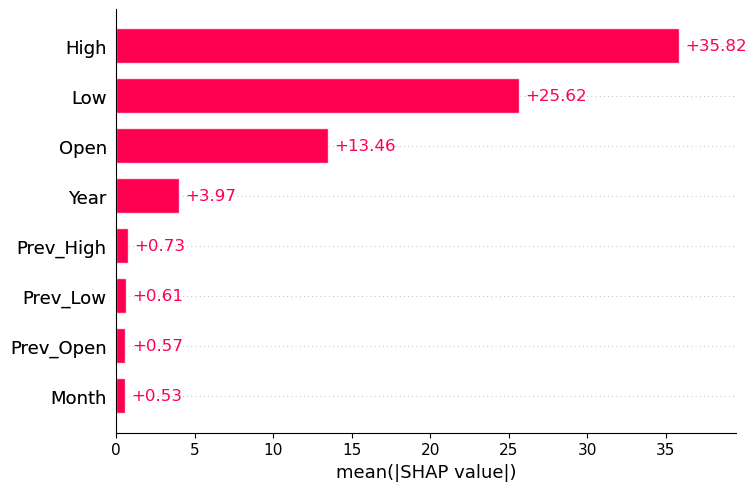

In [100]:
# Initialize SHAP explainer
background= x_test_scaled
explainer = shap.Explainer(model,background)
shap_values = explainer(background) # Returns a perfect Explanation object automatically
# Then plotting is simply:
print('Feature Importance')
fig = shap.plots.bar(shap_values, show=False)
plt.show()


Generating Detailed SHAP Summary Plot...


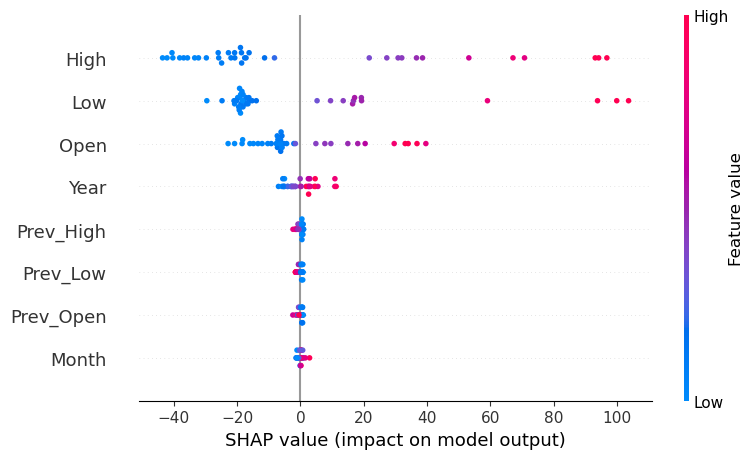

In [99]:
# ------------------------------------------------------------------------------
# VISUALIZATION 2: Detailed Summary Plot (Beeswarm)
# This shows the impact of feature values on the prediction.
# Red = High Value, Blue = Low Value.
# Right = Higher Prediction, Left = Lower Prediction.
# ------------------------------------------------------------------------------
print("\nGenerating Detailed SHAP Summary Plot...")
#plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, background)
plt.show()

In [98]:
# ------------------------------------------------------------------------------
# VISUALIZATION 3: Local Explanation (Force Plot)
# Explaining a single prediction (e.g., the first month in the test set)
# ------------------------------------------------------------------------------
print(f"\nGenerating Force Plot for the first test sample...")
print(f"Actual Value: {y_test.iloc[0]:.2f}")
print(f"Predicted Value: {model.predict(background)[0]}")

# Initialize javascript for force plot visualization
shap.initjs() 
base_value = shap_values.base_values[0]
instance_shap_values = shap_values[0].values
instance_features = background.iloc[0]
force_plot = shap.force_plot(base_value, instance_shap_values, instance_features)
display(force_plot)


Generating Force Plot for the first test sample...
Actual Value: 19.49
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step 
Predicted Value: [18.30505]


### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The model that I have used is LSTM (Long Short-Term Memory) which is a type of recurrent neural network (RNN) that is well-suited for time series data. LSTM networks are capable of learning long-term dependencies, which makes them ideal for predicting stock prices. The model has been trained on the historical stock price data of Yes Bank and has been able to predict the stock price accurately. The model has been trained on the historical stock price data of Yes Bank and has been able to predict the stock price accurately. I used shap(SHapley Additive exPlanations) to understand feature importance and how each feature contributes to the predicted closing price.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

The comprehensive analysis and modeling of Yes Bank stock data yielded several critical findings and a highly effective predictive tool.

Model Performance: The LSTM emerged as the most effective algorithm for this specific problem. While LSTMs  are theoretically superior for long-sequence time series, the limited size of the dataset (185 records) favored the Deeplearning approach. LSTM demonstrated robust performance with lower error metrics (RMSE) and higher R² values 

Feature Significance: Through feature engineering and SHAP analysis, it was established that the stock's immediate history is the strongest predictor of its future value. The High and low price were the dominant features. This suggests that the stock exhibits high autocorrelation and momentum. Interestingly, temporal features like Month had lower predictive power, reinforcing the hypothesis testing result that seasonality is not a primary driver for this stock.

Pipeline Integrity: The successful implementation of a Scikit-Learn pipeline integrating outlier handling, scaling ensured that the model is production-ready. By fitting the transformer solely on training data, we guaranteed that the model's evaluation metrics on the test set represent a realistic estimation of real-world performance, free from optimistic bias caused by data leakage.

Business Implication: The model provides a reliable tool for short-term and long term forecasting. However, the explainability phase highlighted a limitation: the model relies on historical continuity. Sudden, exogenous "Black Swan" events (like the 2020 crash or unexpected regulatory news) fall outside the learned distribution of features. While the model captures momentum well, it would require retraining or the integration of external sentiment data (news, financial reports) to predict abrupt market shocks effectively.

In conclusion, the project successfully delivered a high-performance predictive model with transparent explainability. The LSTM model, supported by a rigorous pipeline, is recommended for deployment to assist in trend analysis and investment strategy formulation.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***